# Chapter 1 — Python / NumPy Warm-up

**Goals**

- Refresh Python basics relevant to ML: lists, dicts, functions, comprehensions.
- Get fluent with NumPy: arrays, shape, broadcasting, vectorization.
- Read tabular data with Pandas.
- Plot with Matplotlib: scatter, histogram, line.

**Prereqs:** Python 3.10+, conda env `aicourse` (see `requirements.txt`).


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

print(f'numpy      {np.__version__}')
print(f'pandas     {pd.__version__}')
print(f'matplotlib {plt.matplotlib.__version__}')

numpy      2.4.6
pandas     3.0.3
matplotlib 3.10.9


## 2. Python crash refresher

Quick examples of the Python features you will use most often: list / dict comprehensions, `enumerate`, `zip`, simple functions.

In [2]:
squares = [x ** 2 for x in range(6)]
print('squares:', squares)

name_to_age = {'alice': 30, 'bob': 25, 'carol': 27}
youngest = min(name_to_age, key=name_to_age.get)
print('youngest:', youngest)

for i, name in enumerate(name_to_age):
    print(i, name, name_to_age[name])

squares: [0, 1, 4, 9, 16, 25]
youngest: bob
0 alice 30
1 bob 25
2 carol 27


In [3]:
def mean(values):
    return sum(values) / len(values)

print('mean([1,2,3,4]) =', mean([1, 2, 3, 4]))

mean([1,2,3,4]) = 2.5


## 3. NumPy arrays

An ML dataset is almost always represented as a 2-D NumPy array `X` of shape `(n_samples, n_features)`. Get comfortable with array creation, shape, and basic ops first.

In [4]:
x = np.array([1.0, 2.0, 3.0, 4.0])
X = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

print('x.shape =', x.shape, '  x.dtype =', x.dtype)
print('X.shape =', X.shape, '  X.dtype =', X.dtype)
print('X[:, 0] =', X[:, 0])     # first column
print('X[1, :] =', X[1, :])     # second row

x.shape = (4,)   x.dtype = float64
X.shape = (3, 3)   X.dtype = int64
X[:, 0] = [1 4 7]
X[1, :] = [4 5 6]


In [5]:
zeros = np.zeros((2, 3))
ones  = np.ones((2, 3))
rand  = rng.standard_normal(size=(2, 3))
print('zeros:\n', zeros)
print('ones:\n',  ones)
print('rand:\n',  rand)

zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
ones:
 [[1. 1. 1.]
 [1. 1. 1.]]
rand:
 [[ 0.30471708 -1.03998411  0.7504512 ]
 [ 0.94056472 -1.95103519 -1.30217951]]


## 4. Broadcasting

NumPy auto-aligns arrays of different shapes via *broadcasting*. This is how you write fast, vectorized code without explicit loops.

In [6]:
X = np.arange(12).reshape(3, 4)
col_mean = X.mean(axis=0)          # shape (4,)
X_centered = X - col_mean          # broadcasts col_mean across rows
print('X:\n', X)
print('col_mean:', col_mean)
print('X_centered:\n', X_centered)
print('column means after centering:', X_centered.mean(axis=0))

X:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
col_mean: [4. 5. 6. 7.]
X_centered:
 [[-4. -4. -4. -4.]
 [ 0.  0.  0.  0.]
 [ 4.  4.  4.  4.]]
column means after centering: [0. 0. 0. 0.]


## 5. Vectorization vs. Python loops

Whenever you can replace a Python `for` loop with a NumPy expression, do it. NumPy's underlying C/SIMD code is 10×-100× faster, and the code is shorter.

In [7]:
import time

n = 1_000_000
a = rng.standard_normal(n)
b = rng.standard_normal(n)

t0 = time.perf_counter()
py_dot = sum(x * y for x, y in zip(a, b))
t1 = time.perf_counter()
np_dot = a @ b
t2 = time.perf_counter()

print(f'Python loop : {t1 - t0:.4f} s, result = {py_dot:.2f}')
print(f'NumPy @     : {t2 - t1:.4f} s, result = {np_dot:.2f}')
print(f'Speed-up    : {(t1 - t0) / (t2 - t1):.1f}x')

Python loop : 0.1068 s, result = 559.64
NumPy @     : 0.0006 s, result = 559.64
Speed-up    : 178.6x


## 6. Useful NumPy ops you will see in this course

- `np.dot(a, b)` / `a @ b` — matrix or vector inner product.
- `np.linalg.norm(x)` — Euclidean norm.
- `np.argmin(x)` / `np.argmax(x)` — index of min / max.
- `np.where(cond, a, b)` — elementwise if-else.
- `np.linspace(a, b, n)` — `n` evenly spaced points in `[a, b]`.

In [8]:
x = np.array([3.0, 4.0])
print('||x||_2 =', np.linalg.norm(x))

scores = np.array([0.1, 0.8, 0.05, 0.7])
print('argmax(scores) =', np.argmax(scores))

vals = np.array([-2, -1, 0, 1, 2])
print('relu(vals) =', np.where(vals > 0, vals, 0))

||x||_2 = 5.0
argmax(scores) = 1
relu(vals) = [0 0 0 1 2]


## 7. Pandas DataFrames

Pandas wraps a 2-D table with named columns and an index. It is the standard way to load CSV files and do quick data inspection in Python.

In [9]:
df = pd.DataFrame({
    'height_cm': [165, 170, 158, 180, 172],
    'weight_kg': [60, 72, 55, 85, 68],
    'sex':       ['F', 'M', 'F', 'M', 'M'],
})
df

,height_cm,weight_kg,sex
0,165,60,F
1,170,72,M
2,158,55,F
3,180,85,M
4,172,68,M


In [10]:
print('shape   :', df.shape)
print('columns :', list(df.columns))
print('dtypes  :\n', df.dtypes, sep='')
df.describe(include='all')

shape   : (5, 3)
columns : ['height_cm', 'weight_kg', 'sex']
dtypes  :
height_cm    int64
weight_kg    int64
sex            str
dtype: object


,height_cm,weight_kg,sex
count,5.000000,5.000000,5
unique,NaN,NaN,2
top,NaN,NaN,M
freq,NaN,NaN,3
mean,169.000000,68.000000,NaN
std,8.185353,11.597414,NaN
min,158.000000,55.000000,NaN
25%,165.000000,60.000000,NaN
50%,170.000000,68.000000,NaN
75%,172.000000,72.000000,NaN


## 8. Reading a CSV

We will load the *Iris* dataset from scikit-learn and wrap it in a DataFrame so you see the typical I/O pattern.

In [11]:
from sklearn.datasets import load_iris

data = load_iris(as_frame=True)
iris = data.frame                       # DataFrame with features and target
iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
print('shape:', iris.shape)
print('missing values per column:')
print(iris.isna().sum())

shape: (150, 5)
missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


## 9. Plotting with Matplotlib

Three plots cover 80% of what you need at this stage: **scatter** for two-feature relationships, **histogram** for a single feature's distribution, **line** for a quantity that changes over an index (e.g. loss over epoch).

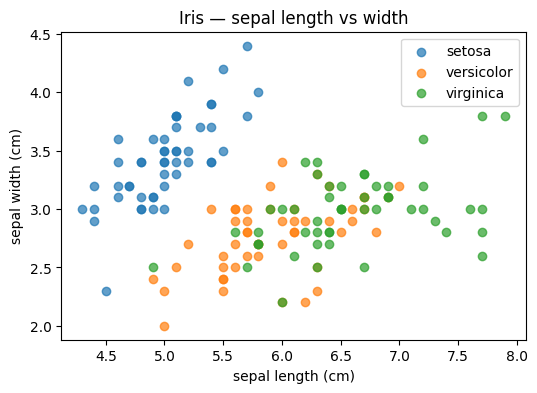

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
for cls, color in zip(data.target_names, ['tab:blue', 'tab:orange', 'tab:green']):
    mask = iris['target'] == list(data.target_names).index(cls)
    ax.scatter(iris.loc[mask, 'sepal length (cm)'],
               iris.loc[mask, 'sepal width (cm)'],
               label=cls, alpha=0.7, color=color)
ax.set_xlabel('sepal length (cm)')
ax.set_ylabel('sepal width (cm)')
ax.set_title('Iris — sepal length vs width')
ax.legend()
plt.show()

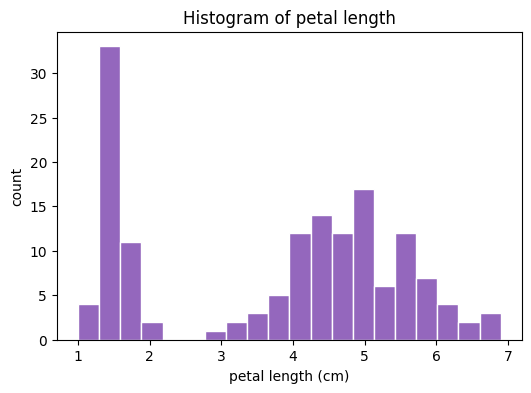

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(iris['petal length (cm)'], bins=20, color='tab:purple', edgecolor='white')
ax.set_xlabel('petal length (cm)')
ax.set_ylabel('count')
ax.set_title('Histogram of petal length')
plt.show()

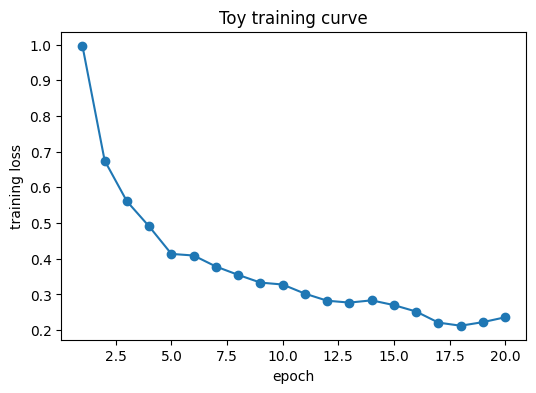

In [15]:
epochs = np.arange(1, 21)
loss   = 1.0 / np.sqrt(epochs) + rng.normal(0, 0.02, size=epochs.shape)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs, loss, marker='o')
ax.set_xlabel('epoch')
ax.set_ylabel('training loss')
ax.set_title('Toy training curve')
plt.show()

## 10. Summary

- NumPy gives you fast, vectorized array math. ML data is stored as a 2-D array of shape `(n_samples, n_features)`.
- Broadcasting lets you operate on arrays of different shapes without writing loops.
- Pandas reads tables; DataFrame has `.shape`, `.dtypes`, `.head()`, `.describe()`, `.isna()`.
- Matplotlib's scatter / hist / line plots cover most quick visualizations.

**Next:** `notebooks/chapter_01_linear_algebra.ipynb` — linear algebra you actually need for ML.